In [1]:
%cd ../
%load_ext autoreload
%autoreload 2

/Users/matthaei/Documents/code/python/bachelor-project


In [2]:
MIGRATE_DATABASE = False

In [3]:
from src.weather_stations.weather_station_service import WeatherStationService
from src.measurements.measurement_service import MeasurementService
from src.calculation.calculation_service import CalculationService
from src.wind_turbines.wind_turbines_service import WindTurbinesService
from src.database.database_service import DatabaseService
from src.aggregation.aggregation_service import AggregationService
from omegaconf import DictConfig, OmegaConf
from hydra import compose, initialize_config_dir
import os

/Users/matthaei/Documents/code/python/bachelor-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Initialize Hydra configuration
config_dir = os.path.abspath("./conf")

# Initialize Hydra with the config directory
with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(config_name="config")

In [5]:
database_service = DatabaseService(cfg)

if MIGRATE_DATABASE:
    database_service.create_tables()

## Load all measurements

In [6]:
aggregation_service = AggregationService(cfg, database_service)

In [7]:
aggregations_df = aggregation_service.get_aggregated_data_for_last_24_hours()

In [8]:
aggregations_df

,avg_extrapolated_hub_height_wind_speed,has_prediction,num_rows,record_date,sum_pred_power_production
0,4.624485,0,4798,2025-09-17 02:10:00,734415.0
1,4.521602,0,4798,2025-09-17 02:20:00,655682.0
2,4.389583,0,4798,2025-09-17 02:30:00,542511.0
3,4.377802,0,4798,2025-09-17 02:40:00,558660.0
4,4.351222,0,4798,2025-09-17 02:50:00,572300.0
...,...,...,...,...,...
139,0.936403,1,4798,2025-09-18 01:20:00,0.0
140,0.937959,1,4798,2025-09-18 01:30:00,0.0
141,0.933725,1,4798,2025-09-18 01:40:00,0.0
142,0.933604,1,4798,2025-09-18 01:50:00,0.0


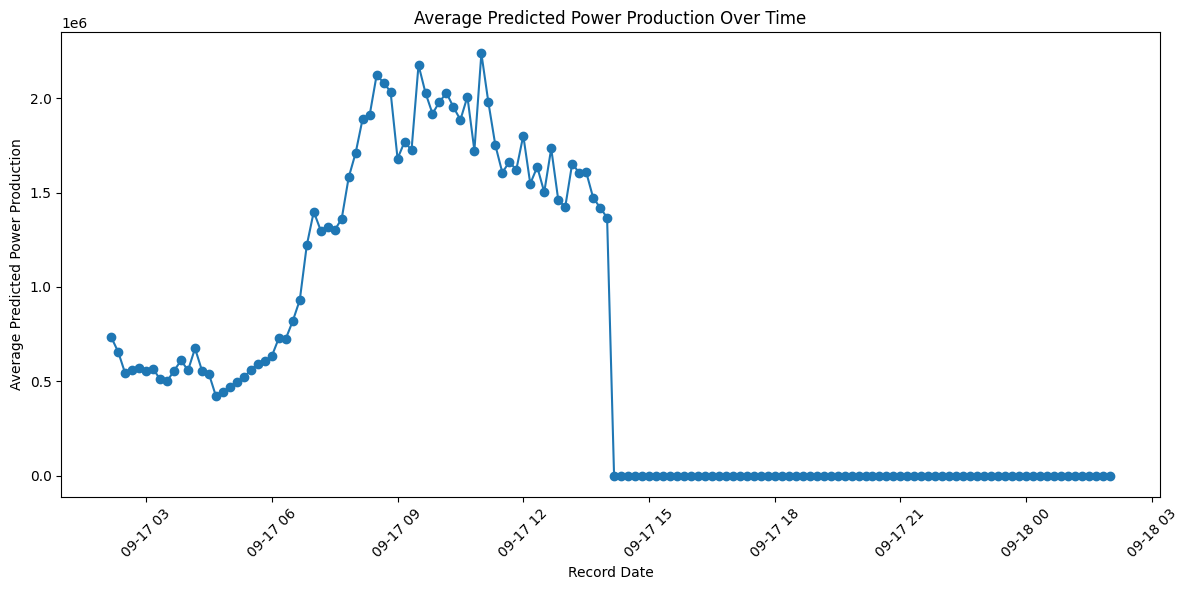

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(aggregations_df['record_date'], aggregations_df['sum_pred_power_production'], marker='o', linestyle='-')
plt.xlabel('Record Date')
plt.ylabel('Average Predicted Power Production')
plt.title('Average Predicted Power Production Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Load for one wind turbine

In [10]:
one_turbine_df = aggregation_service.get_data_for_one_turbine_for_last_24_hours("SEE978883707494")

In [11]:
one_turbine_df

,extrapolated_hub_height_wind_speed,is_prediction,pred_power_production,record_date
0,4.344311,False,215.0,2025-09-17 02:10:00
1,4.440074,False,215.0,2025-09-17 02:20:00
2,4.283869,False,215.0,2025-09-17 02:30:00
3,4.248259,False,134.0,2025-09-17 02:40:00
4,4.332481,False,215.0,2025-09-17 02:50:00
...,...,...,...,...
139,0.945559,True,0.0,2025-09-18 01:20:00
140,0.947112,True,0.0,2025-09-18 01:30:00
141,0.942897,True,0.0,2025-09-18 01:40:00
142,0.942776,True,0.0,2025-09-18 01:50:00


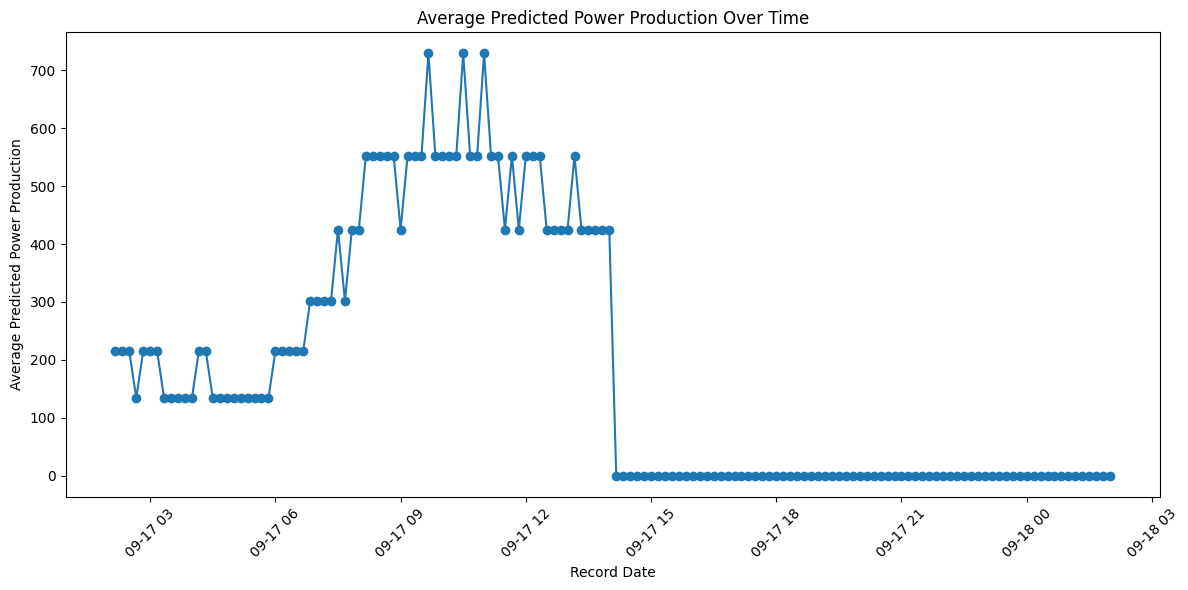

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(one_turbine_df['record_date'], one_turbine_df['pred_power_production'], marker='o', linestyle='-')
plt.xlabel('Record Date')
plt.ylabel('Average Predicted Power Production')
plt.title('Average Predicted Power Production Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
